# EDA: DC 311 Service + Weather (2021-2025)

## Project Background
The District of Columbia 311 system records resident requests for city services, such as bulk collection, parking enforcement, and pothole repair. These requests reflect both infrastructure conditions and seasonal demand patterns across wards.

Understanding how service volume changes over time, location, and weather conditions helps support better city operations, including maintenance prioritization and resource planning.

## Notebook Purpose

This notebook is prepared for the **final project presentation**. It provides concise, presentation-ready exploratory analysis using 2021-2025 DC311 service data and matching weather data.

Key outputs:
1. Top 30 services by total request count
2. Total pothole requests by ward
3. Pearson correlation between pothole counts and weather features


## Workflow

1. Load 2021-2025 service request CSV files and clean key fields.
2. Build service-level summary (Top 30) and ward-level pothole summary.
3. Fetch/load Ward 3 weather cache using project-standard query settings.
4. Aggregate hourly weather to daily and compute Pearson correlation heatmap.


In [10]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.weather_fetch import write_query_config, fetch_and_save

pd.set_option('display.max_columns', 100)
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


In [ ]:
REPO = Path('/data/rpan/course/spring-2026-dc-311')
YEARS = [2021, 2022, 2023, 2024, 2025]
SERVICE_FILES = [
    (2021, '311_City_Service_Requests_in_2021.csv'),
    (2022, '311_City_Service_Requests_in_2022.csv'),
    (2023, '311_City_Service_Requests_in_2023.csv'),
    (2024, '311_City_Service_Requests_in_2024.csv'),
    (2025, '311_City_Service_Requests_in_2025.csv'),
]
REQUIRED_COLS = ['ADDDATE', 'WARD', 'SERVICECODEDESCRIPTION']


In [12]:
service_frames = []
for year, fname in SERVICE_FILES:
    fp = REPO / fname
    df_y = pd.read_csv(fp, usecols=REQUIRED_COLS)
    df_y['year'] = year
    service_frames.append(df_y)

service_df = pd.concat(service_frames, ignore_index=True)
service_df['SERVICECODEDESCRIPTION'] = (
    service_df['SERVICECODEDESCRIPTION']
    .fillna('Unknown')
    .astype(str)
    .str.strip()
)
service_df = service_df[service_df['SERVICECODEDESCRIPTION'] != '']
service_df['WARD'] = service_df['WARD'].fillna('Unknown').astype(str).str.strip()
service_df['date'] = pd.to_datetime(service_df['ADDDATE'], errors='coerce').dt.date
service_df = service_df.dropna(subset=['date']).reset_index(drop=True)

print(f'Loaded rows: {len(service_df):,}')
print(f'Date range: {service_df["date"].min()} -> {service_df["date"].max()}')
print(f'Unique services: {service_df["SERVICECODEDESCRIPTION"].nunique():,}')
print(f'Unique wards: {service_df["WARD"].nunique():,}')


Loaded rows: 2,035,731
Date range: 2021-01-01 -> 2026-01-01
Unique services: 167
Unique wards: 10


## 1) Top 30 Services by Total Request Count

,SERVICECODEDESCRIPTION,count
0,Bulk Collection,340007
1,Parking Enforcement,267577
2,Scheduled Yard Waste,118100
3,Trash Collection - Missed,96849
4,Illegal Dumping,77842
5,Rodent Inspection and Treatment,77084
6,DC Government Information,68254
7,Residential Parking Permit Violation,67757
8,Sanitation Enforcement,65647
9,Roadway Signs,54635


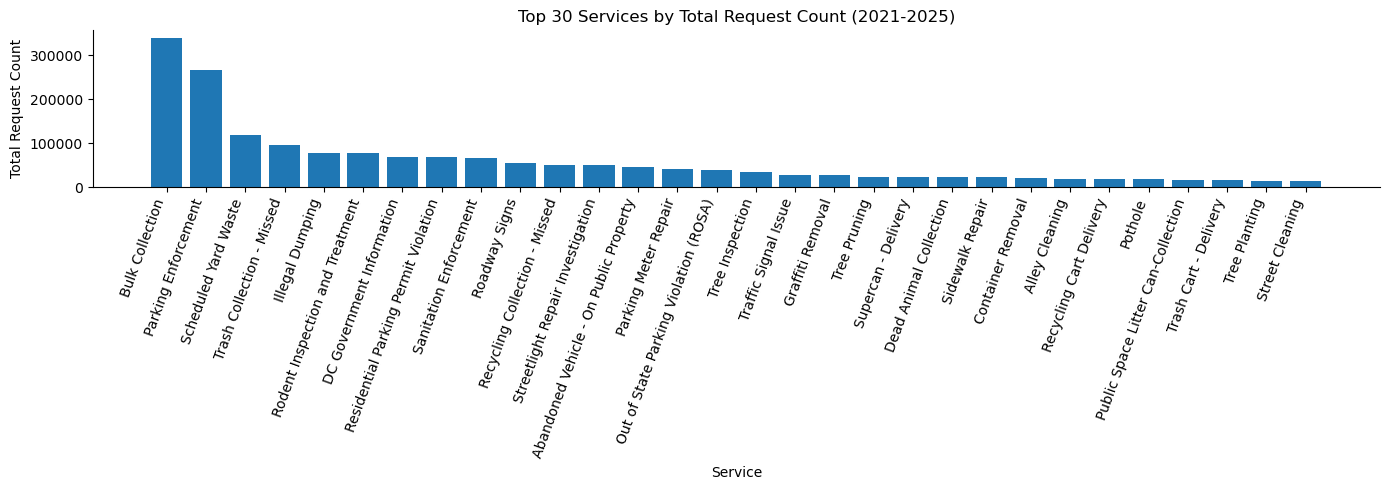

In [13]:
service_count_df = (
    service_df.groupby('SERVICECODEDESCRIPTION', as_index=False)
    .size()
    .rename(columns={'size': 'count'})
    .sort_values('count', ascending=False)
    .reset_index(drop=True)
)

top_n = 30
top_services_df = service_count_df.head(top_n).copy()
display(top_services_df)

plt.figure(figsize=(14, 5))
plt.bar(top_services_df['SERVICECODEDESCRIPTION'], top_services_df['count'])
plt.title(f'Top {top_n} Services by Total Request Count (2021-2025)')
plt.xlabel('Service')
plt.ylabel('Total Request Count')
plt.xticks(rotation=70, ha='right')
plt.tight_layout()
plt.show()


## 2) Total Pothole Requests by Ward

,WARD,count
0,Ward 3,3192
1,Ward 5,2652
2,Ward 4,2315
3,Ward 2,2085
4,Ward 6,1955
5,Ward 8,1803
6,Ward 7,1724
7,Ward 1,1419
8,Null,260
9,Unknown,6


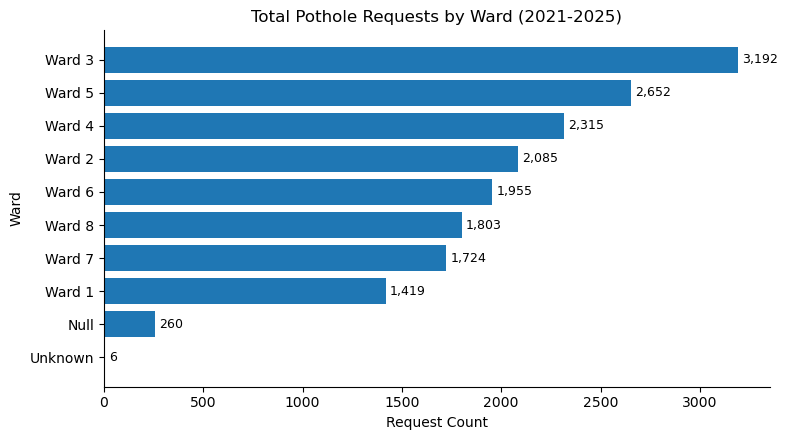

Selected ward (max pothole requests): Ward 3 (3,192)


In [14]:
pothole_df = service_df[service_df['SERVICECODEDESCRIPTION'] == 'Pothole'].copy()
ward_pothole_df = (
    pothole_df.groupby('WARD', as_index=False)
    .size()
    .rename(columns={'size': 'count'})
    .sort_values('count', ascending=False)
    .reset_index(drop=True)
)

display(ward_pothole_df)

plot_df = ward_pothole_df.sort_values('count', ascending=True)
plt.figure(figsize=(8, 4.5))
bars = plt.barh(plot_df['WARD'], plot_df['count'])
for b in bars:
    w = int(b.get_width())
    plt.text(w + 20, b.get_y() + b.get_height()/2, f'{w:,}', va='center', fontsize=9)
plt.title('Total Pothole Requests by Ward (2021-2025)')
plt.xlabel('Request Count')
plt.ylabel('Ward')
plt.tight_layout()
plt.show()

selected_ward_value = ward_pothole_df.loc[0, 'WARD']
selected_ward_slug = selected_ward_value.lower().replace(' ', '')
selected_ward_label = selected_ward_value
selected_ward_total = int(ward_pothole_df.loc[0, 'count'])
print(f'Selected ward (max pothole requests): {selected_ward_label} ({selected_ward_total:,})')


### Figure Description (Total Pothole Requests by Ward)

This chart compares cumulative pothole request totals across wards for 2021-2025.
Request burden is uneven across geography, indicating meaningful spatial heterogeneity in pothole demand.
Ward 3 has the highest total in this dataset, so it is selected as the primary ward for downstream forecasting and weather-feature analysis.


## 3) Weather Extraction

Use Ward 3 centroid and 2020-12-01 to 2025-12-31 query window.

In [15]:
if selected_ward_slug != 'ward3':
    raise ValueError('Only ward3 weather centroid is preconfigured in this notebook. Update coordinates for other wards if needed.')

cfg_path = write_query_config(
    ward='Ward 3',
    lat=38.939126092220974,
    lon=-77.077979511738,
    start_date='2020-12-01',
    end_date='2025-12-31',
    configs_dir='data/weather_query_configs',
)
fetch_and_save(cfg_path, cache_dir='data/weather_cache', force=False)


Config written → data/weather_query_configs/weather_ward3_20201201_20251231.json
Cache hit — loaded data/weather_cache/weather_ward3_20201201_20251231.parquet
  Saved at: 2026-03-18T04:58:10.966919+00:00


(                           date  temperature_2m  precipitation  snowfall
 0     2020-11-30 23:00:00-05:00            8.65            0.0       0.0
 1     2020-12-01 00:00:00-05:00            8.10            0.0       0.0
 2     2020-12-01 01:00:00-05:00            7.35            0.0       0.0
 3     2020-12-01 02:00:00-05:00            7.45            0.0       0.0
 4     2020-12-01 03:00:00-05:00            7.50            0.0       0.0
 ...                         ...             ...            ...       ...
 44563 2025-12-31 18:00:00-05:00            0.55            0.0       0.0
 44564 2025-12-31 19:00:00-05:00            0.10            0.0       0.0
 44565 2025-12-31 20:00:00-05:00            0.35            0.0       0.0
 44566 2025-12-31 21:00:00-05:00            0.75            0.0       0.0
 44567 2025-12-31 22:00:00-05:00            1.20            0.0       0.0
 
 [44568 rows x 4 columns],
 {'label': 'weather_ward3_20201201_20251231',
  'ward': 'Ward 3',
  'description': 